In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from moabb.paradigms import P300
from moabb.datasets import *


paradigm = P300(resample=48)
dataset = BNCI2014008()
epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
     subjects=[8],
     return_epochs=True
)
session = meta['session'][1]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]



BNCI2014008 has been renamed to BNCI2014_008. BNCI2014008 will be removed in version 1.1.
The dataset class name 'BNCI2014008' must be an abbreviation of its code 'BNCI2014-008'. See moabb.datasets.base.is_abbrev for more information.
/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 4200 events (all good), 0 – 1 s (baseline off), ~65.9 MB, data loaded,
 'Target': 700
 'NonTarget': 3500>
  warn(f"warnEpochs {epochs}")


Adding metadata with 3 columns
Adding metadata with 3 columns
4200 matching events found
No baseline correction applied


/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/paradigms/base.py:350: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [3]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

X = tl.tensor(epochs.get_data())
y = labels

In [4]:
#%env PYTHONWARNINGS=error

In [5]:
from sklearn.model_selection import StratifiedKFold
from hoda.hoda import BTTDA, GreedyBTTDA, HODA, trunc_eigh
from hoda.cov import mode_scatter
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import  warnings
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFwe
from sklearn.preprocessing import StandardScaler
import warnings
from joblib import parallel_backend
from joblib import Parallel
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectFwe
from hoda.classification import SelectF

clf = make_pipeline(
    SelectF(),
    FunctionTransformer(tl.to_numpy),
    StandardScaler(),
    LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
)

bttda = GreedyBTTDA(
    max_blocks=4,
    hoda_params=dict(
        rank=None,
        max_iter=128,
        tol=1e-8,
        init ='random',
        shrinkage='oas',
        toeplitz=None,#(1,),
        obj='tr',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=True,
        random_state=42,
        delta=None,
    ),
    #rank_grid=[1],
    verbose=True,
    extra_train_info=False,
    n_jobs=1,
    cv= StratifiedKFold(random_state=42,shuffle=True),
    truncate=True,
    clf=clf,
)
bttda.fit(X,y, test=True)

Model selection block 1/4...

Trying rank (1, 1)	score: 0.9359
Trying rank (2, 2)	score: 0.9332
Trying rank (4, 4)	score: 0.9242
Trying rank (8, 8)	score: 0.9363
Trying rank (8, 16)	score: 0.9344
Trying rank (8, 32)	score: 0.9382

Selected rank (8, 32) with score 0.9382
New ranks: [(8, 32)]


Model selection block 2/4...

Trying rank (1, 1)	score: 0.9395
Trying rank (2, 2)	score: 0.9385
Trying rank (4, 4)	score: 0.9385
Trying rank (8, 8)	score: 0.9395
Trying rank (8, 16)	score: 0.9403
Trying rank (8, 32)	score: 0.9404

Selected rank (8, 32) with score 0.9404
New ranks: [(8, 32), (8, 32)]


Model selection block 3/4...

Trying rank (1, 1)	score: 0.9411
Trying rank (2, 2)	score: 0.9412
Trying rank (4, 4)	score: 0.9413
Trying rank (8, 8)	score: 0.9408
Trying rank (8, 16)	score: 0.9406
Trying rank (8, 32)	score: 0.9406

Selected rank (4, 4) with score 0.9413
New ranks: [(8, 32), (8, 32), (4, 4)]


Model selection block 4/4...

Trying rank (1, 1)	score: 0.9410
Trying rank (2, 2)	score: 0.94

GreedyBTTDA(clf=Pipeline(steps=[('selectf', SelectF()),
                                ('functiontransformer',
                                 FunctionTransformer(func=<function NumpyBackend.to_numpy at 0x150e05aefce0>)),
                                ('standardscaler', StandardScaler()),
                                ('lineardiscriminantanalysis',
                                 LinearDiscriminantAnalysis(shrinkage='auto',
                                                            solver='lsqr'))]),
            cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
            hoda_params={'delta': None, 'extra_train_info': False,
                         'init': 'random', 'max_iter': 128, 'obj': 'tr',
                         'random_state': 42, 'rank': (8, 32),
                         'shrinkage': 'oas', 'solver': 'lanczos',
                         'taper': False, 'toeplitz': None, 'tol': 1e-08,
                         'verbose': False},
            max_blocks=4, n_jobs=1, verbose=True)

In [6]:
bttda.model_select_info_

fold  train_score  val_score  n_features  test_score
block rank                                                         
0     (1, 1)      0     0.941583   0.954024           1    0.939210
      (1, 1)      1     0.940913   0.955196           1    0.939230
      (1, 1)      2     0.950105   0.920139           1    0.940013
      (1, 1)      3     0.948961   0.918846           1    0.938076
      (1, 1)      4     0.946693   0.931473           1    0.938779
...             ...          ...        ...         ...         ...
3     (8, 32)     0     0.969901   0.957749         784    0.952654
      (8, 32)     1     0.972564   0.952209         784    0.946012
      (8, 32)     2     0.974771   0.927109         784    0.943394
      (8, 32)     3     0.977125   0.925813         784    0.952745
      (8, 32)     4     0.974572   0.946700         784    0.948129

[120 rows x 5 columns]

In [7]:
bttda.model_select_info_best_

fold  train_score  val_score  n_features  test_score
block rank                                                         
0     (8, 32)     0     0.960893   0.947407         256    0.945591
      (8, 32)     1     0.961559   0.950828         256    0.942110
      (8, 32)     2     0.963533   0.925407         256    0.944417
      (8, 32)     3     0.965758   0.920839         256    0.945561
      (8, 32)     4     0.963286   0.946763         256    0.944839
1     (8, 32)     0     0.967076   0.956818         512    0.946213
      (8, 32)     1     0.970255   0.951470         512    0.943584
      (8, 32)     2     0.972209   0.927591         512    0.943113
      (8, 32)     3     0.973593   0.919739         512    0.944708
      (8, 32)     4     0.971346   0.946460         512    0.943113
2     (4, 4)      0     0.968179   0.956689         528    0.948922
      (4, 4)      1     0.970568   0.951358         528    0.945260
      (4, 4)      2     0.972825   0.927478         528    0.944196
      (4, 4)      3     0.974632   0.923119         528    0.947497
      (4, 4)      4     0.971732   0.947816         528    0.945611
3     (8, 32)     0     0.969901   0.957749         784    0.952654
      (8, 32)     1     0.972564   0.952209         784    0.946012
      (8, 32)     2     0.974771   0.927109         784    0.943394
      (8, 32)     3     0.977125   0.925813         784    0.952745
      (8, 32)     4     0.974572   0.946700         784    0.948129

In [8]:
bttda.model_select_info_best_.groupby(['block', 'rank'])['val_score'].aggregate('mean')

block  rank   
0      (8, 32)    0.938249
1      (8, 32)    0.940416
2      (4, 4)     0.941292
3      (8, 32)    0.941916
Name: val_score, dtype: float64

In [9]:
bttda.model_select_info_best_.groupby(['block', 'rank'])['test_score'].aggregate('mean')

block  rank   
0      (8, 32)    0.944503
1      (8, 32)    0.944146
2      (4, 4)     0.946297
3      (8, 32)    0.948587
Name: test_score, dtype: float64

block  rank  
0      (1, 1)    0.807051
1      (8, 8)    0.820216
2      (8, 8)    0.825298
3      (8, 8)    0.828784
4      (4, 4)    0.829647
5      (8, 8)    0.832404
6      (8, 8)    0.834165
7      (4, 4)    0.835178
Name: val_score, dtype: float64

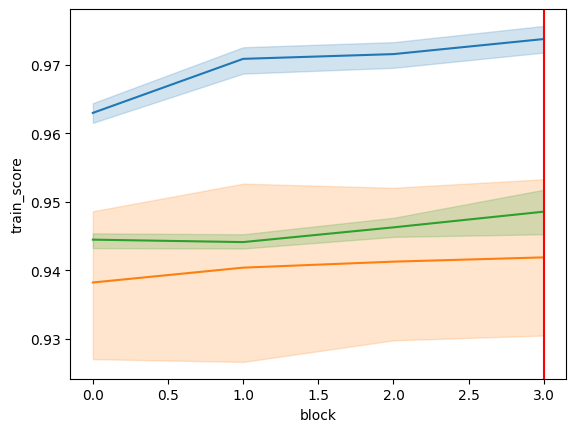

In [10]:
import seaborn as sns 
import matplotlib.pyplot as plt

plt.style.use('default')
sns.lineplot(data=bttda.model_select_info_best_, x='block',y='train_score')
sns.lineplot(data=bttda.model_select_info_best_, x='block',y='val_score')
sns.lineplot(data=bttda.model_select_info_best_, x='block',y='test_score')
plt.axvline(bttda.n_blocks_-1, color='red')

<Axes: xlabel='block', ylabel='n_features'>

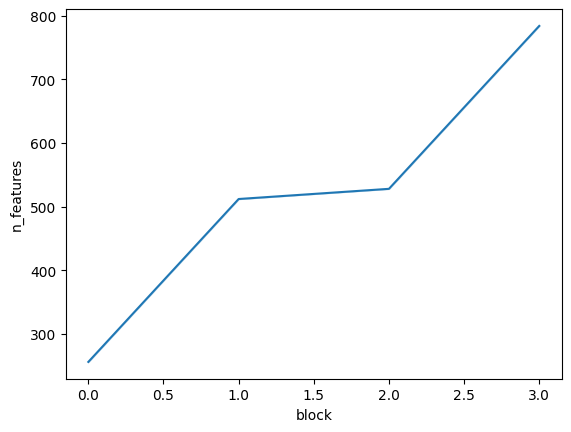

In [11]:
sns.lineplot(data=bttda.model_select_info_best_, x='block',y='n_features')


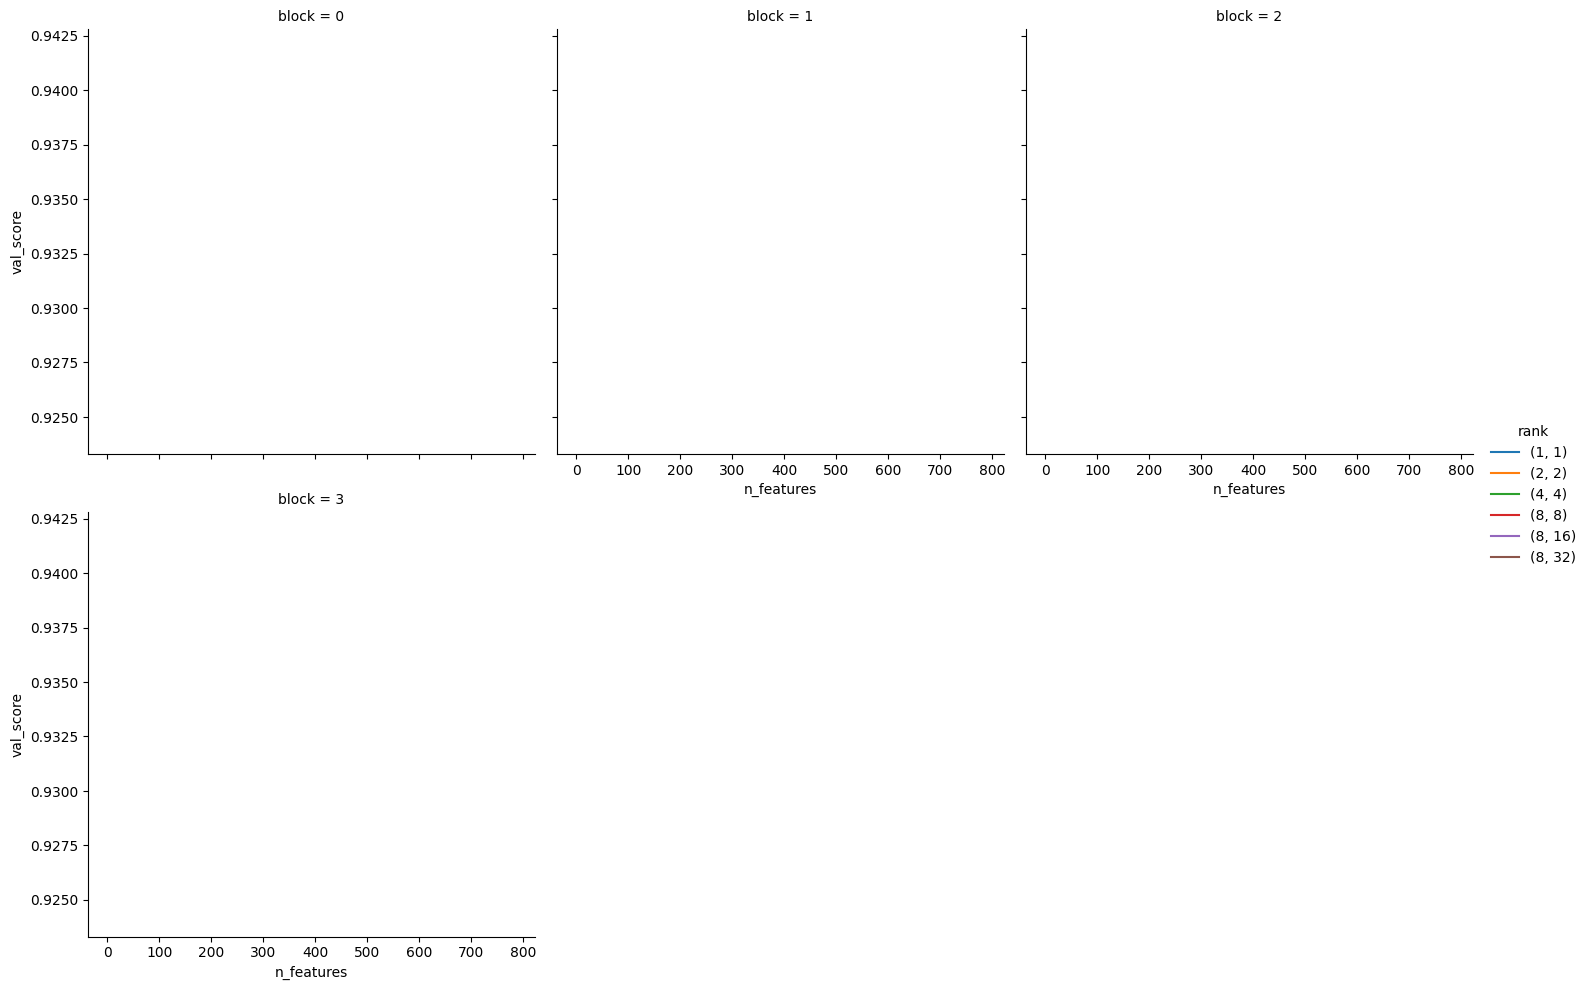

In [12]:
sns.relplot(
    data=bttda.model_select_info_.reset_index(),
    x='n_features',
    y='val_score',
    hue='rank',
    palette='tab10',
    col='block',
    kind='line',
    col_wrap=3,
    errorbar=None,
)
#plt.xscale('log')